### Why multi-input?
Using more information
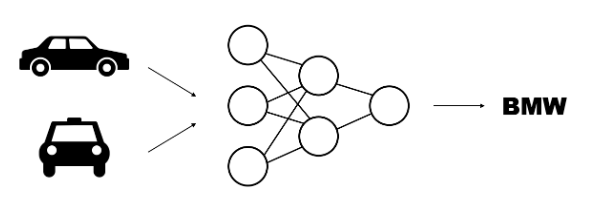
Multi-modal models
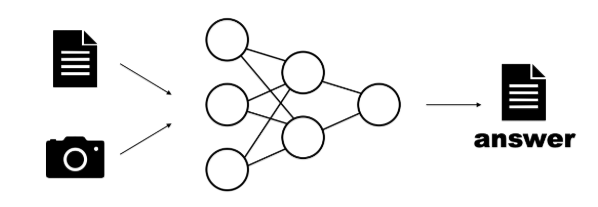
Metric Learning
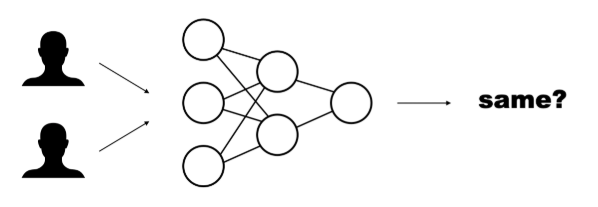
Self-supervised learning
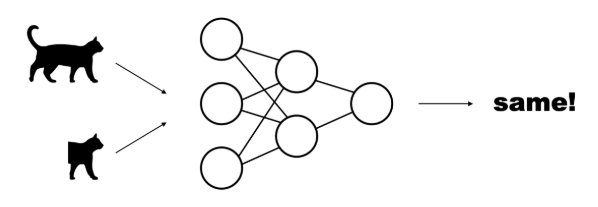

### Example
#### Character classification
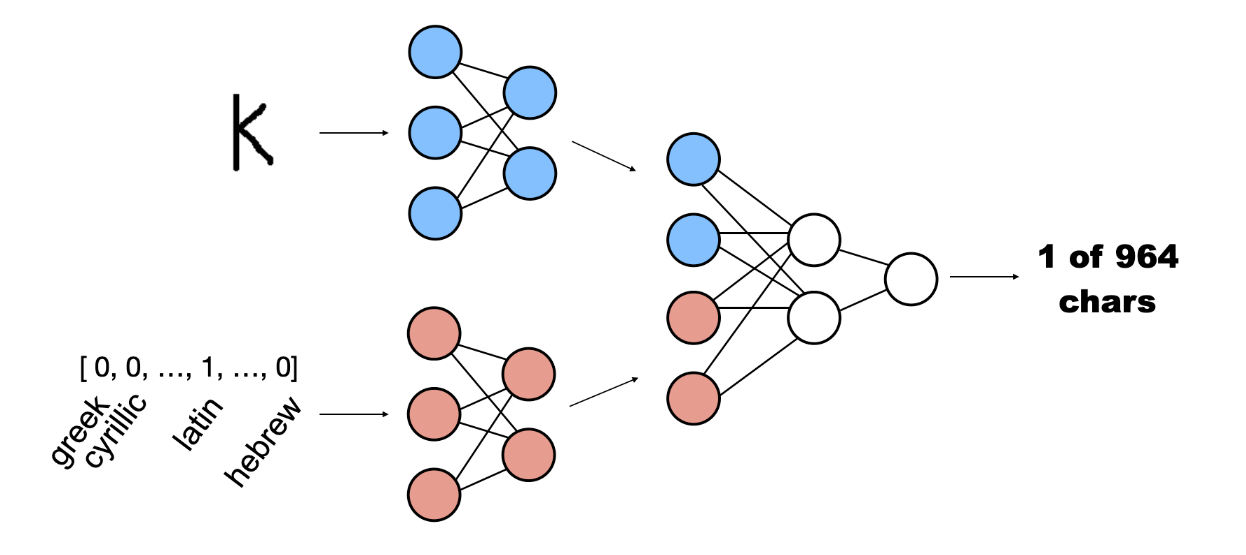

#### Two-input Dataset
- Assign samples and transforms
- Implement `__len__()`
- Load and transform image
- Return both in puts and label

In [ ]:
from torch.utils.data import Dataset
from PIL import Image


class OmniglotDataset(Dataset):
    def __init__(self, transform, samples):
        self.transform = transform
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, alphabet, label = self.samples[idx]
        img = Image.open(img_path).convert('L')
        img = self.transform(img)
        return img, alphabet, label

### Tensor concatenation


In [1]:
import torch

x = torch.tensor([
    [1, 2, 3],
])

y = torch.tensor([
    [4, 5, 6],
])

# Concatenation along axis 0
# 0 for horizontal concatenation
torch.cat((x,y), dim=0)

tensor([[1, 2, 3],
        [4, 5, 6]])

In [2]:
# 1 for vertical concatenation


torch.cat((x,y), dim=1)

tensor([[1, 2, 3, 4, 5, 6]])

### Two-input architecture
`__init__()`:
- Define image processing layer
- Define alphabet processing layer
- Define classifier layer
`forward()`:
- Pass image through image layer
- Pass alphabet through alphabet layer
- Concatenate image and alphabet outputs
- Pass concatenated input through classifier layer

#### Training loop
- Training data consists of three items:
    - Image
    - Alphabet
    - Label
- We pass the model images and alphabets as inputs


In [ ]:
from torch import nn


class Net(nn.module):
    def __init__(self):
        super().__init__()
        self.image_layer = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.MaxPool2d(kernel_size=2),
            nn.ELU(),
            nn.Flatten(),
            nn.Linear(16*32*32, 128),
        )
        self.alphabet_layer = nn.Sequential(
            nn.Linear(30, 8),
            nn.ELU()
        )
        self.classifier = nn.Sequential(
            nn.Linear(128+8, 964),
        )

    def forward(self, x_image, x_alphabet):
        x_image = self.image_layer(x_image)
        x_alphabet = self.alphabet_layer(x_alphabet)
        x = torch.cat((x_image, x_alphabet), dim=1)
        return self.classifier(x)


net = Net()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(net.parameters(), lr=0.01)

for epoch in range(10):
    for img, alpha, labels in dataloader_train:
        optimizer.zero_grad()
        outputs = net(img, alpha)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()